# Workflows et Human-in-the-Loop — Jour 3

Comment organiser un traitement automatique tout en laissant une personne décider
aux moments importants ? Nous allons construire ce circuit avec LangGraph, puis
l'appliquer à un workflow de support email.

Vous allez manipuler un état, relier des étapes, suspendre une exécution et la reprendre.
L'intervention humaine s'appelle **Human-in-the-Loop**, ou **HITL**.

**Comment travailler.** Exécutez les cellules dans l'ordre. Avant chaque essai,
prédisez le résultat ; après, comparez et expliquez l'écart éventuel. Les exercices
restent dans les sections du cours et leur correction est repliée pour vous laisser chercher.
Un noyau Python est le programme qui garde vos variables en mémoire : le redémarrer
efface ces variables. Les premiers exemples ne demandent ni clé API ni appel à un modèle.

## 1. Comprendre un workflow
### 1.1 Agent ou workflow ?

Un **agent** décide dynamiquement des actions à effectuer, tandis qu'un **workflow**
définit explicitement les étapes et les transitions. Un workflow peut comporter
des branches et des boucles : ses règles déterminent les chemins possibles.

Un appel à un **LLM** (grand modèle de langage) ne suffit donc pas à faire un agent.
Dans notre workflow de support, le modèle classe le message et rédige une réponse ;
le code organise les étapes et décide quand demander une validation humaine.
Un workflow peut aussi intégrer un agent dans un de ses nœuds.

![Comparaison entre workflows et agent](../assets/agent_workflow.png)

Le schéma illustre des chemins organisés par le code, à gauche, et une boucle où
le modèle choisit les actions, à droite. Source :
[documentation LangGraph](https://docs.langchain.com/oss/python/langgraph/workflows-agents).

### 1.2 Un dossier qui passe de poste en poste

Imaginez un dossier qui circule dans un service. Chaque poste lit les informations
dont il a besoin et complète le dossier avant de le transmettre.

| Dans notre image | Dans LangGraph | À quoi cela sert |
|---|---|---|
| Le dossier | État (`state`) | Rassembler les données du traitement. |
| Un poste de travail | Nœud (`node`) | Exécuter une fonction qui lit et complète l'état. |
| Une flèche entre deux postes | Arête (`edge`) | Définir une transition. |
| Préparer le circuit | `compile()` | Obtenir un graphe prêt à fonctionner. |
| Déposer un dossier | `invoke()` | Lancer le traitement avec des données. |
| Mettre le dossier en attente | `interrupt()` | Demander une décision avant de continuer. |
| Sauvegarder le dossier et son avancement | Checkpointer | Conserver des instantanés, appelés checkpoints. |
| Le numéro du dossier | `thread_id` | Retrouver le bon fil d'exécution. |
| Une instruction de traitement | `Command` | Reprendre, ou mettre à jour l'état et choisir la suite. |

Cette image aide à suivre le parcours. En Python, l'état sera un **dictionnaire**,
et les postes seront des **fonctions**. Nous allons les lire ensemble dans le premier exemple.

### 1.3 Préparer l'atelier

Choisissez le noyau Python de l'environnement de formation. Les sections 2 et 3
utilisent LangGraph sans modèle d'IA. La section 4 ajoute SQLite ; si nécessaire,
installez son composant depuis un terminal dans l'environnement de formation :

```powershell
uv pip install langgraph-checkpoint-sqlite
```

L'image d'introduction utilise `../assets/agent_workflow.png`. Les affichages de graphes
sont des aides à la lecture : une erreur de rendu ne signifie pas que le workflow est incorrect.
Vous pouvez suivre les parcours écrits dans le texte et poursuivre avec la cellule suivante.
La connexion Mistral et les autres chemins de formation seront expliqués en section 5.

## 2. Construire un workflow avec interruption

**Objectif.** Construire un circuit avec un poste de validation : `START → valider → END`.
Ce poste demande une autorisation avant de produire un résultat. L'action est simulée :
aucun dossier n'est supprimé.

**Quelques repères Python pour lire le code.**

- Un dictionnaire associe des noms à des valeurs : `{"action": "supprimer_dossier"}`.
  `state["action"]` lit la valeur rangée sous la clé `action`.
- `def demander_validation(...)` définit une fonction. Son bloc indenté sera exécuté
  lorsqu'elle sera appelée ; `return` fournit son résultat.
- `if reponse == "oui"` teste la réponse. `==` compare deux valeurs ; `=` affecte une valeur.
- `class MiniState(TypedDict)` décrit les champs du dictionnaire. `action: str` signifie
  « la valeur est un texte ». Ces annotations ne remplissent pas le dossier à votre place.
- Dans `f"...{state['action']}..."`, Python insère la valeur de l'action dans le message.

**Méthode.** La cellule définit le dossier, le poste et les flèches, puis prépare le circuit.

| Appel | Lecture simple |
|---|---|
| `add_node(node="valider", action=demander_validation)` | Enregistrer la fonction sous le nom `valider`. |
| `add_edge(start_key=START, end_key="valider")` | Commencer par ce poste. |
| `add_edge(start_key="valider", end_key=END)` | Terminer après ce poste. |
| `compile(checkpointer=InMemorySaver())` | Préparer le circuit avec une sauvegarde en mémoire. |

On passe `demander_validation` **sans parenthèses** pour enregistrer la fonction.
La compilation prépare le graphe ; seul `invoke()` le lance.

À l'exécution, `interrupt()` expose la demande et rend la main à l'application.
Le checkpointer sauvegarde l'attente. L'application peut ensuite fournir la décision
avec `Command(resume=...)` sur le même `thread_id`.

Documentation : [nœuds](https://reference.langchain.com/python/langgraph/graph/state/StateGraph/add_node)
et [arêtes](https://reference.langchain.com/python/langgraph/graph/state/StateGraph/add_edge).

In [89]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver


# Le nœud reçoit une action et complète ensuite le champ resultat.
class MiniState(TypedDict):
    action: str
    resultat: str


def demander_validation(state: MiniState) -> MiniState:
    # interrupt() suspend le graphe et renvoie ce dictionnaire à l'appelant.
    reponse = interrupt({"action": state["action"], "question": "Autoriser ? (oui/non)"})
    # À la reprise, reponse prend la valeur transmise dans Command(resume=...).
    if reponse == "oui":
        return {"resultat": f" '{state['action']}' exécutée"}
    return {"resultat": f" '{state['action']}' annulée"}


# Définir le parcours unique grâce à StateGraph : début, validation, fin.
mini = StateGraph(MiniState)
# Ajouter un nœud pour demander la validation humaine.
mini.add_node(node="valider", action=demander_validation)
# Ajouter les transitions entre les nœuds.
mini.add_edge(start_key=START, end_key="valider")
# Ajouter la transition vers la fin.
mini.add_edge(start_key="valider", end_key=END)

# Conserver le checkpoint en mémoire pour retrouver la validation en attente.
mini_app = mini.compile(checkpointer=InMemorySaver())
print("Graphe minimal compilé")

Graphe minimal compilé


**Observer le circuit.** La cellule suivante dessine le graphe préparé. Repérez le nœud et les deux arêtes ; ce dessin n’exécute pas la validation.

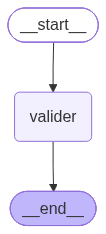

In [90]:
# Dessiner le graphe ne lance pas ses nœuds.
from IPython.display import Image, display, Markdown

display(
    Image(
        mini_app.get_graph().draw_mermaid_png()
    )
)

**Résultat attendu.** `Graphe minimal compilé` confirme que le circuit est prêt,
sans exécuter la validation. Le schéma montre **un nœud** `valider` et **deux arêtes** :
`START → valider` et `valider → END`. `START` et `END` marquent l'entrée et la sortie.

### 2.1 Exécuter, attendre et reprendre

**Objectif.** Observer comment le workflow se suspend pour demander une autorisation, puis reprend avec une réponse humaine.

**Méthode.** Le code réalise quatre étapes :

1. **Identifier le fil d’exécution.**
   La configuration `{"configurable": {"thread_id": "mini-1"}}` permet au checkpointer de retrouver l’état sauvegardé. Nous réutilisons cette même configuration lors de la reprise.

2. **Lancer le workflow.**
   `mini_app.invoke({"action": "supprimer_dossier"}, config)` transmet l’action au graphe. Le nœud `valider` commence son exécution, puis `interrupt()` (spécifié dans la fonction du noeud) la suspend pour demander une autorisation. Le checkpointer conserve l’état et l’appel à `invoke()` rend la main.

3. **Lire la demande de validation.**
   `resultat["__interrupt__"][0]` récupère la première interruption. Son attribut `.value` contient le dictionnaire fourni à `interrupt()`, avec l’action concernée et la question destinée à l’humain. Le premier `print()` affiche cette demande.

4. **Reprendre avec un refus.**
   `mini_app.invoke(Command(resume="non"), config)` transmet la réponse `"non"` au workflow en attente. Le nœud recommence depuis son début ; cette fois, `interrupt()` renvoie la réponse fournie. Le code choisit alors le résultat d’annulation et le graphe atteint `END`.

**Lire une expression pas à pas.** Dans `resultat["__interrupt__"][0].value`,
`["__interrupt__"]` récupère les interruptions, `[0]` sélectionne la première
(Python commence à compter à zéro) et `.value` donne le contenu de la demande.
La clé comporte deux caractères `_` de chaque côté.

In [91]:
# Réutiliser cet identifiant permet de retrouver la même attente à la reprise.
config = {"configurable": {"thread_id": "mini-1"}}

# 1) Lancement : le graphe s'arrête sur l'interruption.
resultat = mini_app.invoke({"action": "supprimer_dossier"}, config)

# Le contenu transmis à interrupt() est accessible dans le résultat de invoke().
interruption = resultat["__interrupt__"][0]
print("Interruption reçue :", interruption.value)

# 2) Décision humaine → reprise sur le MÊME thread_id.
resultat = mini_app.invoke(Command(resume="non"), config)
print("Après reprise :", resultat["resultat"])

Interruption reçue : {'action': 'supprimer_dossier', 'question': 'Autoriser ? (oui/non)'}
Après reprise :  'supprimer_dossier' annulée


**Résultat attendu.** La première invocation affiche la demande, la seconde
indique que `'supprimer_dossier'` est annulée. La décision `"non"` est fournie dans
le code : aucun formulaire n'apparaît automatiquement.

**Observer le dossier.** Le nœud renvoie seulement une mise à jour ; LangGraph conserve
les autres champs de l'état :

```text
État initial :         {"action": "supprimer_dossier"}
Mise à jour du nœud :  {"resultat": " 'supprimer_dossier' annulée"}
État final :          {"action": "supprimer_dossier", "resultat": " 'supprimer_dossier' annulée"}
```

**Attention à la reprise.** Le nœud repart de son début, puis `interrupt()` restitue
la réponse humaine. Un appel externe placé avant l'interruption peut donc se répéter.
Placez un envoi après l'interruption ou dans un nœud distinct. Si une opération doit
pouvoir être répétée sans nouvel effet, on dit qu'elle doit être *idempotente*.

**À vous de jouer — prédire, exécuter, expliquer.**

Avant d’exécuter ce petit essai, prédisez le résultat. La fonction sera-t-elle
appelée à la compilation ou à `invoke()` ? Le nœud recommence-t-il au début à la reprise ?
Exécutez ensuite le code ci-dessous, puis remplacez `"oui"` par `"non"` et recommencez.
Le nouvel identifiant isole chaque essai ; il reste identique entre son lancement et sa reprise.

<details>
<summary>Afficher la correction après votre essai</summary>

La compilation prépare le graphe ; `invoke()` appelle les nœuds. Le premier appel
s'arrête sur la demande. La reprise recommence le nœud et fournit la réponse à `interrupt()`.
Avec `"oui"`, l'action est annoncée exécutée ; avec `"non"`, annulée. Rien n'est réellement envoyé.
Changer d'identifiant **entre** les deux appels empêcherait de retrouver cette attente.

</details>

In [92]:
from uuid import uuid4

# Nouveau dossier à chaque essai, même numéro pour les deux appels de cet essai.
cfg_essai = {"configurable": {"thread_id": f"essai-{uuid4().hex}"}}
pause_essai = mini_app.invoke({"action": "envoyer_un_message"}, cfg_essai)
print("Demande :", pause_essai["__interrupt__"][0].value)

choix_essai = "oui"  # À modifier pour comparer les deux décisions.

fin_essai = mini_app.invoke(Command(resume=choix_essai), cfg_essai)
print("Dossier final :", fin_essai)

Demande : {'action': 'envoyer_un_message', 'question': 'Autoriser ? (oui/non)'}
Dossier final : {'action': 'envoyer_un_message', 'resultat': " 'envoyer_un_message' exécutée"}


**Résultat à comparer à votre prédiction.** Le dossier final garde `action` et ajoute `resultat`. Expliquez pourquoi le choix change le résultat sans ajouter un deuxième nœud au graphe.

## 3. Router après la décision humaine

**Objectif.** Préparer un workflow qui soumet un document à une personne, puis adapte son parcours à la décision reçue : approuver, éditer ou rejeter. Chaque décision doit laisser une trace dans un journal d’audit.

**Méthode.** Le code construit ce fonctionnement en cinq étapes :

1. **Définir les données partagées.**
   `RevueState` décrit l’état du workflow : le `document` à relire, le `verdict` final et le journal `audit`. L’annotation `Annotated[list[dict], operator.add]` définit une règle de fusion appelée **reducer** : chaque nouvelle liste d’entrées est ajoutée au journal existant, au lieu de le remplacer.

2. **Préparer une trace des décisions.**
   La fonction `_entree_audit()` crée un dictionnaire contenant la décision, son horodatage en UTC et les 100 premiers caractères du document. Elle permet de conserver une trace concise et homogène.

3. **Demander une décision humaine.**
   Le nœud `revue_humaine` appelle `interrupt()` avec le document et les choix proposés. Le workflow se suspend alors. Lors de la reprise avec `Command(resume=...)`, la réponse humaine devient la valeur de `decision`, dont le champ `choix` détermine la suite.

4. **Mettre à jour l’état et choisir la destination.**
   Le nœud renvoie un `Command` qui combine les modifications de l’état (`update`) et le choix du prochain nœud (`goto`).

   | Choix reçu | Mise à jour de l’état | Destination |
   |---|---|---|
   | `approuver` | Ajouter une entrée d’audit `approuvé`. | `finaliser` |
   | `editer` | Remplacer le document par le texte fourni et ajouter une entrée `édité`. | `finaliser` |
   | `rejeter` ou tout autre choix | Ajouter une entrée d’audit `rejeté`. | `archiver` |

   Si le choix est `editer` mais que la clé `texte` est absente, le document initial est conservé. L’édition mène directement à la finalisation, sans seconde demande d’approbation.

5. **Assembler et compiler le graphe.**
   Le parcours commence par `revue_humaine`. Ce nœud choisit sa destination avec `Command(goto=...)`, ce qui explique l’absence d’arête fixe en sortie de la revue. `finaliser` attribue le verdict `publié`, tandis qu’`archiver` attribue `archivé (rejeté)` ; les deux conduisent à `END`. La compilation avec `InMemorySaver` prépare la sauvegarde en mémoire nécessaire à la reprise.

**Comprendre le journal avant son annotation.** Un reducer est la règle qui rassemble
l'ancien contenu d'un champ et ce qu'un nœud ajoute. Ici, `operator.add` additionne des
listes, donc les concatène :

```text
Audit existant :   [{"decision": "reçu"}]
Nouvelle entrée :  [{"decision": "édité"}]
Audit obtenu :    [{"decision": "reçu"}, {"decision": "édité"}]
```

`Annotated[list[dict], operator.add]` signifie « une liste de dictionnaires, à fusionner
par ajout ». Pour un champ ordinaire comme `document`, une nouvelle valeur remplace l'ancienne.
`doc[:100]` prélève les 100 premiers caractères ; l'UTC est une référence horaire commune.

**Lire `.get()`.** `decision.get("choix")` lit un choix et renvoie `None` s'il est absent.
`decision.get("texte", state["document"])` garde le document si la clé `texte` manque.
Avec `decision["texte"]`, une clé absente provoquerait une erreur.

In [93]:
import operator
from typing import Annotated, Literal
from datetime import datetime, timezone

# Définir le type de l'état pour la revue humaine.
class RevueState(TypedDict):
    document: str
    verdict: str
    audit: Annotated[list[dict], operator.add]  # reducer : concatène les entrées

# Définir une fonction pour créer une entrée d'audit.
def _entree_audit(decision: str, doc: str) -> dict:
    # Horodater la décision et conserver un extrait, sans recopier tout le document.
    return {
        "decision": decision,
        "horodatage": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "extrait": doc[:100],
    }

# Les destinations annotées permettent aussi de dessiner les routes possibles.
# La décision réelle sera prise par Command(goto=...) à la reprise.
def revue_humaine(state: RevueState) -> Command[Literal["finaliser", "archiver"]]:
    decision = interrupt({
        "document": state["document"],
        "action": "Relire : approuver / editer / rejeter",
    })
    # decision est un dict fourni par l'humain, ex. {"choix": "editer", "texte": "..."}
    choix = decision.get("choix")

    if choix == "approuver":
        return Command(update={"audit": [_entree_audit("approuvé", state["document"])]},
                       goto="finaliser")
    # Enregistrer le texte corrigé et l’audit avant de passer à la finalisation.
    if choix == "editer":
        nouveau = decision.get("texte", state["document"])
        return Command(update={"document": nouveau,
                               "audit": [_entree_audit("édité", nouveau)]},
                       goto="finaliser")
    # Tout choix autre qu’approuver ou éditer conduit ici au rejet.
    return Command(update={"audit": [_entree_audit("rejeté", state["document"])]},
                   goto="archiver")

# Définir les nœuds de finalisation et d’archivage.
def finaliser(state: RevueState) -> RevueState:
    return {"verdict": "publié"}

# Définir le nœud d’archivage.
def archiver(state: RevueState) -> RevueState:
    return {"verdict": "archivé (rejeté)"}


revue = StateGraph(RevueState)
revue.add_node("revue_humaine", revue_humaine)
revue.add_node("finaliser", finaliser)
revue.add_node("archiver", archiver)
revue.add_edge(START, "revue_humaine")
# Le nœud de revue choisit sa destination avec Command : aucune arête fixe en sortie.
revue.add_edge("finaliser", END)
revue.add_edge("archiver", END)

revue_app = revue.compile(checkpointer=InMemorySaver())
print("Graphe de revue compilé (3 décisions, 2 destinations : finaliser / archiver)")

Graphe de revue compilé (3 décisions, 2 destinations : finaliser / archiver)


**Après exécution — résultat attendu.** Le message de compilation annonce trois décisions et deux destinations. `revue_app` est prêt à recevoir un document ; le verdict et l'audit ne seront produits qu'après une décision humaine.

**Observer le choix de parcours.** Dessinez le graphe de revue et retrouvez ses deux destinations. Les routes possibles sont décrites dans l’annotation du nœud ; la décision sera prise à la reprise.

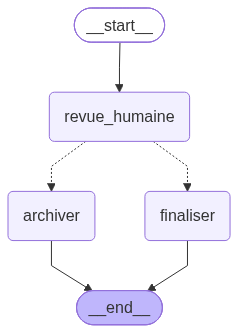

In [94]:
# Dessiner le graphe ne lance pas ses nœuds.
display(
    Image(
        revue_app.get_graph().draw_mermaid_png()
    )
)

### 3.1 Corriger et finaliser le document

**Objectif.** Vérifier qu’une correction humaine est intégrée au document avant sa finalisation et que cette intervention est enregistrée dans le journal d’audit.

**Méthode.** Le code déroule le scénario en quatre étapes :

1. **Identifier le dossier de revue.**
   La configuration utilise le `thread_id` `"revue-edit"`. Cet identifiant permet de retrouver la même exécution lors de la reprise.

2. **Soumettre le document et lire la demande.**
   Le premier appel à `invoke()` transmet la note initiale au workflow. Le nœud `revue_humaine` atteint `interrupt()` et suspend l’exécution. L’affichage de `etat["__interrupt__"][0].value["action"]` présente alors les choix proposés : approuver, éditer ou rejeter.

3. **Fournir une correction humaine.**
   Le dictionnaire `decision` contient le choix `"editer"` et le nouveau texte. Dans cet exemple, la décision est écrite directement dans le code ; une application pourrait la recueillir dans une interface de relecture.

4. **Reprendre et finaliser.**
   `Command(resume=decision)` transmet la réponse au workflow en attente, avec la même configuration `cfg`. Le nœud de revue remplace le document, ajoute une entrée d’audit `édité` et dirige l’exécution vers `finaliser`. Ce dernier attribue le verdict `publié`, puis le graphe se termine.

In [95]:
# Scénario : corriger le document, puis le finaliser dans le même parcours.
cfg = {"configurable": {"thread_id": "revue-edit"}}

# Lancer la revue : le graphe s'arrête sur l'interruption.
etat = revue_app.invoke({"document": "Note de service : congés fermés en août."}, cfg)
print("", etat["__interrupt__"][0].value["action"])

 Relire : approuver / editer / rejeter


**Reprendre maintenant.** La cellule précédente a affiché la demande de relecture. Celle-ci fournit la correction et termine le même dossier. Prédisez le document final avant de l’exécuter.

In [96]:
# Fournir le choix et le texte corrigé, comme le ferait une interface de relecture.
decision = {"choix": "editer", "texte": "Note : les congés d'août sont soumis à validation."}
# Injecter la décision dans l’interruption du même fil d’exécution.
final = revue_app.invoke(Command(resume=decision), cfg)

print("Verdict :", final["verdict"])
print("Document :", final["document"])
print("Audit   :", final["audit"])

Verdict : publié
Document : Note : les congés d'août sont soumis à validation.
Audit   : [{'decision': 'édité', 'horodatage': '2026-09-09T09:30:00+00:00', 'extrait': "Note : les congés d'août sont soumis à validation."}]


**Après exécution — résultat attendu.** Le verdict doit être `publié`, le document doit devenir `Note : les congés d'août sont soumis à validation.` et l'audit doit contenir une entrée `édité`, avec un horodatage et un extrait du texte corrigé.

**Ce qu'il faut retenir.** `resume` fournit la réponse à l'attente ; `update` décrit
ce qui change dans le dossier ; `goto` choisit le poste suivant. Ici, éditer conduit
directement à la finalisation. « Publier » et « archiver » modifient seulement le verdict.

**À vous de jouer — tester les destinations.**

Prédisez le verdict pour `approuver`, `editer` et `rejeter`, puis utilisez la cellule
suivante pour essayer ces trois valeurs. Dans le cas d’une édition, quels champs changent ?
Le journal est-il remplacé ou complété ?

<details>
<summary>Afficher la correction après votre essai</summary>

`approuver` et `editer` conduisent à `finaliser`, donc au verdict `publié`.
`rejeter` conduit à `archiver`, donc à `archivé (rejeté)`.
L'édition remplace `document`, ajoute une entrée dans `audit` et la finalisation renseigne
`verdict`. Le reducer conserve les anciennes entrées du journal.

</details>

In [97]:
from uuid import uuid4

# Réexécuter cette cellule avec un choix différent ; chaque essai crée son propre dossier.
cfg_revue_essai = {"configurable": {"thread_id": f"revue-essai-{uuid4().hex}"}}
revue_app.invoke({"document": "Texte initial."}, cfg_revue_essai)
decision_essai = {"choix": "rejeter", "texte": "Texte corrigé."}
fin_revue_essai = revue_app.invoke(Command(resume=decision_essai), cfg_revue_essai)
print("Dossier après la décision :", fin_revue_essai)

Dossier après la décision : {'document': 'Texte initial.', 'verdict': 'archivé (rejeté)', 'audit': [{'decision': 'rejeté', 'horodatage': '2026-09-09T09:30:00+00:00', 'extrait': 'Texte initial.'}]}


**Résultat attendu avec le choix fourni.** Le verdict est `archivé (rejeté)`, le texte initial reste présent et le journal contient `rejeté`. Comparez ensuite avec une édition.

## 4. Conserver le dossier avec SQLite

### 4.1 Sauvegarder une validation en attente

**L’image à retenir.** La mémoire est le dossier posé sur le bureau : il disparaît avec le processus. SQLite est un fichier où l’on range une copie pour la retrouver plus tard.

**Objectif.** Conserver l’état d’un workflow interrompu dans un fichier, afin de pouvoir reprendre la validation après la fermeture de la connexion ou un redémarrage du programme.

**Méthode.** Le code prépare le stockage, lance la revue et ferme la connexion en cinq étapes :

1. **Initialiser la base de démonstration.**
   `DB` désigne le fichier local `checkpoints_t1.db`. S’il existe déjà, `os.remove(DB)` le supprime pour recommencer l’exercice avec une base vide. Cette suppression efface les checkpoints et les validations en attente des exécutions précédentes.

2. **Identifier le fil d’exécution.**
   Le `thread_id` `"revue-durable"` identifie la revue dans les sauvegardes. La reprise devra utiliser ce même identifiant et le même fichier SQLite.

In [98]:
import os
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

DB = "checkpoints_t1.db"
if os.path.exists(DB):
    os.remove(DB)  # Réinitialisation de démonstration : les anciennes attentes sont effacées.
cfg_durable = {"configurable": {"thread_id": "revue-durable"}}

3. **Connecter le graphe au stockage SQLite.**
   `sqlite3.connect()` ouvre la base et crée le fichier si nécessaire. Le paramètre `check_same_thread=False` autorise l’utilisation de la connexion depuis les threads d’exécution du graphe.
   `revue.compile(checkpointer=SqliteSaver(conn1))` prépare ensuite le workflow avec un checkpointer qui sauvegarde les checkpoints dans cette base, plutôt qu’en mémoire (via `InMemorySaver` comme vu précédemment).

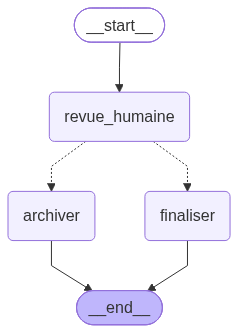

In [99]:
# Dessiner le graphe ne lance pas ses nœuds.
# Première connexion : sauvegarder le graphe interrompu sur disque.
# Autoriser l’usage de la connexion par les threads d’exécution du graphe.
conn1 = sqlite3.connect(DB, check_same_thread=False)
app1 = revue.compile(checkpointer=SqliteSaver(conn1))
display(Image(app1.get_graph().draw_mermaid_png()))

4. **Lancer la revue jusqu’à l’interruption.**
   `app1.invoke()` soumet le document `"Contrat fournisseur à signer."`. Le nœud de revue atteint `interrupt()` : le workflow se suspend, son état est sauvegardé et l’appel rend la main. Aucune décision humaine n’a encore été fournie.

5. **Fermer la connexion.**
   `conn1.close()` libère la connexion SQLite. Le fichier conserve les checkpoints enregistrés : fermer la connexion ne supprime pas la validation en attente. Le processus Python, lui, reste actif.

In [100]:
# L’exécution atteint interrupt() et sauvegarde l’attente avant de rendre la main.
app1.invoke({"document": "Contrat fournisseur à signer."}, cfg_durable)
print("Première connexion : graphe interrompu, état écrit sur disque.")
conn1.close()  # ferme la connexion ; le processus Python reste actif

Première connexion : graphe interrompu, état écrit sur disque.


**Résultat attendu.** Le message `Première connexion : graphe interrompu, état écrit sur disque.` s’affiche. Le fichier `checkpoints_t1.db` contient les données nécessaires pour retrouver la revue en attente. Une cellule suivante pourra rouvrir ce fichier et vérifier la reprise avec le même `thread_id`.

**À retenir.** La persistance sur disque permet de conserver l’attente au-delà de la connexion actuelle. Pour reprendre une attente existante, il ne faut pas relancer la suppression du fichier placée dans la cellule d’initialisation de cette section.

### 4.2 Retrouver et reprendre la validation

**Objectif.** Vérifier qu’une nouvelle connexion SQLite permet de retrouver la revue interrompue, puis de la terminer avec une approbation humaine.

**Méthode.** Le code réalise quatre étapes :

1. **Rouvrir la base et préparer le graphe.**
   `sqlite3.connect(DB, check_same_thread=False)` ouvre une nouvelle connexion au fichier utilisé précédemment. Le graphe `revue` est compilé avec un nouveau `SqliteSaver` associé à cette connexion. Les checkpoints existants sont conservés.

2. **Consulter l’état sauvegardé.**
   `app2.get_state(cfg_durable)` retrouve le checkpoint grâce au même `thread_id`. Cette consultation ne relance pas le workflow. L’attribut `etat_repris.next` indique le nœud qui doit reprendre son exécution : ici, `revue_humaine`.

3. **Approuver et reprendre la revue.**
   `Command(resume={"choix": "approuver"})` fournit la décision humaine à l’interruption sauvegardée. Le nœud `revue_humaine` recommence depuis son début et `interrupt()` restitue cette décision. Le workflow ajoute une entrée d’audit `approuvé`, puis rejoint `finaliser`, qui attribue le verdict `publié`.

4. **Lire le résultat et fermer la connexion.**
   Les derniers affichages présentent le verdict et le journal d’audit. `conn2.close()` ferme ensuite la connexion sans supprimer les checkpoints enregistrés dans le fichier.

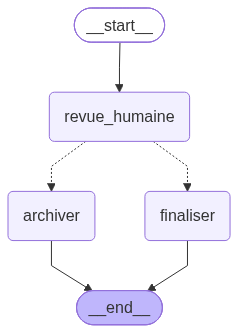

In [101]:
# Dessiner le graphe ne lance pas ses nœuds.
# Nouvelle connexion : retrouver la même attente depuis le fichier.
conn2 = sqlite3.connect(DB, check_same_thread=False)
app2 = revue.compile(checkpointer=SqliteSaver(conn2))
display(Image(app2.get_graph().draw_mermaid_png()))

**Vérifier la sauvegarde.** La nouvelle application est prête. Consultez d’abord le nœud en attente, puis approuvez : le verdict doit devenir `publié`.

In [102]:
# L'état est reconstruit depuis le disque, pas depuis la mémoire.
etat_repris = app2.get_state(cfg_durable)
print("Nœud en attente :", etat_repris.next)  # ('revue_humaine',)

# Le même thread_id associe cette approbation à la validation sauvegardée.
final = app2.invoke(Command(resume={"choix": "approuver"}), cfg_durable)
print("Verdict après reprise :", final["verdict"])
print("Audit :", final["audit"])
conn2.close()

Nœud en attente : ('revue_humaine',)
Verdict après reprise : publié
Audit : [{'decision': 'approuvé', 'horodatage': '2026-09-09T09:30:01+00:00', 'extrait': 'Contrat fournisseur à signer.'}]


**Après exécution — résultat attendu.** Le nœud en attente doit être `('revue_humaine',)`. Après reprise, le verdict doit être `publié` et l'audit doit contenir la décision `approuvé`. Ces sorties montrent que l'attente a été retrouvée depuis le fichier ; elles ne simulent pas un redémarrage réel du noyau.

Comme repères de progression, `InMemorySaver` convient aux démonstrations,
SQLite à une persistance locale sur une machine, et un backend externe adapté,
par exemple PostgreSQL, peut répondre aux besoins d'un déploiement distribué.
Ce ne sont pas des règles absolues : le choix dépend notamment de la concurrence,
du volume et de l'exploitation. La logique du graphe reste indépendante du stockage.

**À vous de jouer — retrouver le dossier.**

Fermer une connexion efface-t-il les checkpoints ? Que faut-il conserver pour
reprendre après un redémarrage ? Pourquoi ne faut-il pas réexécuter la suppression de la base ?

<details>
<summary>Afficher la correction après votre essai</summary>

Le fichier conserve les checkpoints après fermeture. Il faut le même fichier,
le même `thread_id` et les définitions du graphe pour recompiler l'application.
Supprimer le fichier efface l'attente. Les cellules ont ouvert deux connexions ;
elles n'ont pas réellement redémarré Python.

</details>

## 5. Construire le workflow de support email

Réunissons les mécanismes précédents : le workflow lit un email, le classe, collecte
du contexte, rédige une réponse puis l'envoie, avec une revue humaine si nécessaire.
La classification et la rédaction utilisent Mistral ; la recherche documentaire,
la création du ticket et l'envoi sont simulés.

### 5.1 Connecter le modèle Mistral

**Objectif.** Préparer la connexion au service qui classera les emails et rédigera les réponses.
Un client est ici un objet Python qui sait communiquer avec ce service.

**Méthode.** Charger les variables du fichier `.env`, un fichier de configuration,
puis préparer l'URL du serveur, appelée aussi *endpoint*. La clé `MISTRAL_API_KEY`
sert à s'authentifier et `MISTRAL_SERVER_URL` indique où joindre le service.

Ces cellules supposent que le répertoire de travail est celui du notebook :
`env_utils` vient de `../util` et le contrôle lit `../.env`. Hors de l'environnement
de formation, adaptez ces chemins et configurez les deux variables.
Le réglage de l'URL et l'utilitaire sont fournis : concentrez-vous sur les appels au modèle.

In [103]:
import os
from dotenv import load_dotenv, find_dotenv

# Charger les variables du fichier .env sans remplacer celles déjà définies.
load_dotenv(find_dotenv())

# Éviter de doubler le suffixe /v1 lorsque le serveur le fournit déjà.
_base = os.environ["MISTRAL_SERVER_URL"].rstrip("/")
MISTRAL_ENDPOINT = _base if _base.endswith("/v1") else _base + "/v1"

import sys
# Rendre accessible l’utilitaire fourni dans le répertoire de formation.
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "util"))
from env_utils import doublecheck_env

doublecheck_env("../.env")

MISTRAL_API_KEY=****uLt0
MISTRAL_SERVER_URL=****l.ai
LANGSMITH_API_KEY=****here
LANGSMITH_TRACING=false
LANGSMITH_PROJECT=****tral


**Après exécution — résultat attendu.** `MISTRAL_ENDPOINT` contient l'URL à utiliser par le client. L'utilitaire affiche un contrôle des variables, avec les valeurs masquées, ou signale l'absence du fichier `../.env`. Aucun appel au modèle n'a encore lieu. Une erreur sur `MISTRAL_SERVER_URL` indique que cette variable doit être renseignée avant de continuer.

**Objectif.** Créer le client LLM qui servira à classer les emails et à rédiger les réponses.

**Méthode.** Créer un objet `ChatMistralAI` avec le modèle choisi, l'URL préparée et une température de zéro pour limiter la variabilité des réponses.

In [104]:
from langchain_mistralai import ChatMistralAI

MODEL = "mistral-medium-latest"

# Créer le client ; les requêtes seront envoyées lors des appels à invoke().
llm = ChatMistralAI(
    model=MODEL,
    temperature=0,
    endpoint=MISTRAL_ENDPOINT,
)

print(f"LLM : {MODEL} · temperature=0")

LLM : mistral-medium-latest · temperature=0


**Après exécution — résultat attendu.** La ligne `LLM : mistral-medium-latest · temperature=0` confirme la création du client `llm`. Elle ne confirme pas encore l'accès au serveur : le premier appel au modèle aura lieu dans le scénario de support.

### 5.2 Définir les données du support

```text
START → read_email → classify_intent
                         ├→ search_documentation ─┐
                         └→ bug_tracking ─────────┴→ write_response
                                                        ├→ send_reply → END
                                                        └→ human_review
                                                              ├→ send_reply → END
                                                              └→ END (rejet)
```

La classification utilise `with_structured_output` pour obtenir les champs du
schéma Pydantic ci-dessous. Ces valeurs alimentent ensuite la règle de validation.

**Objectif.** Organiser les données du workflow de support : encadrer la classification produite par Mistral et définir les informations partagées entre les nœuds.

**Méthode.** Le code définit deux structures complémentaires.

1. **Encadrer la classification avec `EmailClassification`.**
   Cette classe Pydantic décrit la réponse structurée attendue du modèle.

   | Champ | Rôle | Valeurs attendues |
   |---|---|---|
   | `intent` | Identifier la nature de la demande. | `question`, `bug`, `facturation`, `fonctionnalite` ou `complexe` |
   | `urgency` | Évaluer le niveau d’urgence. | `basse`, `moyenne`, `haute` ou `critique` |
   | `topic` | Nommer brièvement le sujet. | Une chaîne de caractères |
   | `summary` | Résumer la demande. | Une chaîne de caractères |

   `Literal` limite les catégories acceptées. `Field(description=...)` précise le sens des champs pour guider la sortie structurée du modèle. Pydantic vérifie la conformité des données au schéma ; il ne garantit pas que la classification est pertinente.

In [105]:
from typing import Literal, Optional
from pydantic import BaseModel, Field


class EmailClassification(BaseModel):
    """Schéma que le modèle Mistral doit remplir pour classer l'email."""
    # Limiter les catégories permet au code de routage de tester des valeurs connues.
    intent: Literal["question", "bug", "facturation", "fonctionnalite", "complexe"] = Field(
        description="Intention principale de l'email"
    )
    urgency: Literal["basse", "moyenne", "haute", "critique"] = Field(
        description="Niveau d'urgence"
    )
    topic: str = Field(description="Sujet en quelques mots")
    summary: str = Field(description="Résumé en une phrase")

**Décrire l’état partagé avec `EmailState`.**
   Ce `TypedDict` décrit les champs que les nœuds liront et renseigneront au fil du traitement.

   | Groupe | Champs | Utilité |
   |---|---|---|
   | Entrée | `email_content`, `sender_email`, `email_id` | Conserver le message, son expéditeur et son identifiant. |
   | Contexte | `classification`, `ticket_id`, `search_results` | Stocker la classification, le ticket éventuel et les résultats documentaires. |
   | Sortie | `draft_response`, `sent` | Conserver le brouillon et indiquer si l’envoi a été effectué. |
   | Audit | `audit` | Accumuler les décisions tracées par le workflow. |

   `Optional[...]` autorise une valeur `None`. Cela ne crée pas de valeur par défaut et ne rend pas automatiquement la clé facultative dans le `TypedDict`.

   Pour `audit`, `Annotated[list[dict], operator.add]` précise la règle de fusion utilisée par LangGraph : les nouvelles entrées sont ajoutées à la liste existante, au lieu de la remplacer.

**Deux outils, deux rôles.** `TypedDict` décrit un dictionnaire pour la lecture et
les outils de typage ; Pydantic vérifie les données quand on crée un objet de son modèle.
Dans les deux cas, le code des nœuds doit encore produire les valeurs.
Un objet Pydantic pourra être converti en dictionnaire avec `.model_dump()`.
`None` signifie « aucune valeur » ; `False` signifie « non » pour un indicateur booléen.

In [106]:
class EmailState(TypedDict):
    # Entrée
    email_content: str
    sender_email: str
    email_id: str
    # Champs renseignés progressivement par les nœuds de classification et de recherche.
    classification: Optional[dict]
    ticket_id: Optional[str]
    search_results: Optional[list]
    # Sortie
    draft_response: Optional[str]
    sent: Optional[bool]
    # Ajouter les nouvelles décisions sans écraser le journal existant.
    audit: Annotated[list[dict], operator.add]


print("Schémas définis")

Schémas définis


**Résultat attendu.** Le message `Schémas définis` s’affiche. Les deux classes sont disponibles pour les cellules suivantes, mais aucun email n’a encore été classé et aucun appel à Mistral n’a été effectué.

**À retenir.** `EmailClassification` encadre la sortie de classification du modèle ; `EmailState` décrit les données qui circulent dans l’ensemble du workflow.

### 5.3 Définir les étapes et la règle de validation

Le HITL est ici une **règle métier du workflow**, appliquée après la rédaction :

- urgence basse ou moyenne : traitement automatique, sauf demande complexe ;
- urgence haute ou critique : validation humaine ;
- demande complexe : validation humaine, quelle que soit l'urgence.

L'humain intervient lorsque le risque ou la complexité le justifie, sans devoir
valider chaque étape. Dans `write_response`, `besoin_revue` applique cette règle
à la classification du modèle ; seul `human_review` déclenche l'interruption.

**À vous de jouer — appliquer la règle sans modèle.**

Décidez du parcours avant de lire la correction :

| Urgence | Intention | Votre prédiction |
|---|---|---|
| basse | question | … |
| moyenne | bug | … |
| haute | question | … |
| basse | complexe | … |

Expliquez pourquoi le dernier cas demande une revue. Les mêmes valeurs doivent conduire
au même parcours, même si le texte rédigé par le modèle varie.

<details>
<summary>Afficher la correction après votre essai</summary>

Les deux premiers cas vont vers l'envoi automatique ; les deux derniers vers la
revue humaine. La complexité suffit à imposer une revue, même avec une urgence basse.
Le modèle propose une classification ; la règle Python décide du parcours.

</details>

**Classer le message.**

**Objectif.** Obtenir des catégories que le code pourra tester.

**Méthode.** Préparer `with_structured_output(EmailClassification)`, puis définir la lecture et la classification. `read_email` renvoie `{}` car le message est déjà dans le dossier : aucune mise à jour n’est nécessaire.

**Exemple de données à observer lors de l’exécution du workflow.** L’entrée sera un email ; la sortie sera une mise à jour comme `{"classification": {"intent": "question", "urgency": "basse", "topic": "Accès", "summary": "Mot de passe oublié."}}`. C’est un exemple de forme, pas une prédiction du modèle. `.model_dump()` transforme la réponse Pydantic en dictionnaire.

In [107]:
import uuid

# Préparer des réponses conformes au schéma ; aucun appel réseau n’est encore lancé.
structured_llm = llm.with_structured_output(EmailClassification)


def read_email(state: EmailState) -> EmailState:
    # Ici, un vrai connecteur (IMAP/API) analyserait l'email. On passe l'entrée telle quelle.
    return {}


def classify_intent(state: EmailState) -> EmailState:
    prompt = (
        "Classe cet email de support client.\n\n"
        f"Expéditeur : {state['sender_email']}\n"
        f"Email : {state['email_content']}"
    )
    classification = structured_llm.invoke(prompt)
    # On stocke un dict (sérialisable par le checkpointer).
    return {"classification": classification.model_dump()}

**Après cette cellule.** Les fonctions sont définies, mais pas encore exécutées. Les résultats décrits ci-dessus seront produits lors du traitement des emails.

**Collecter le contexte.**

**Objectif.** Donner à la rédaction des informations complémentaires.

**Méthode.** Définir une recherche documentaire et un suivi des bugs. Ces fonctions simulent des résultats ; elles ne consultent aucun service externe. `uuid` sert seulement à fabriquer un identifiant de ticket.

**Exemple de données à observer lors de l’exécution du workflow.** Une classification sur l’accès alimentera `search_results`. Une intention `bug` alimentera aussi `ticket_id`, par exemple `BUG-a1b2c3d4`. Les deux fonctions mettent à jour des champs distincts.

**Lire une valeur de secours.** `(state.get("classification") or {})` utilise la classification si elle est renseignée, sinon un dictionnaire vide. La suite `.get("topic", "")` lit le sujet ou fournit un texte vide.

In [108]:
def search_documentation(state: EmailState) -> EmailState:
    # Recherche documentaire simulée ; le thème suivant ajoutera des sources réelles.
    sujet = (state.get("classification") or {}).get("topic", "")
    return {"search_results": [f"[doc] Article pertinent sur : {sujet}"]}


def bug_tracking(state: EmailState) -> EmailState:
    # Simuler un identifiant de ticket uniquement pour les bugs ; aucun outil externe n’est appelé.
    if (state.get("classification") or {}).get("intent") == "bug":
        return {"ticket_id": f"BUG-{uuid.uuid4().hex[:8]}"}
    return {}

**Après cette cellule.** Les fonctions sont définies, mais pas encore exécutées. Les résultats décrits ci-dessus seront produits lors du traitement des emails.

**Rédiger et choisir le parcours.**

**Objectif.** Préparer la réponse, puis décider si une personne doit la relire.

**Méthode.** Rassembler le contexte, appeler le modèle et calculer `besoin_revue`. `or` signifie qu’une seule des deux conditions suffit : urgence élevée ou demande complexe. `Command` enregistre le brouillon et choisit sa destination.

**Exemple de données à observer lors de l’exécution du workflow.** L’entrée comprendra la classification et le contexte ; la sortie sera un `Command` avec `draft_response` et une destination. `"\n".join(...)` assemble les textes sur des lignes séparées. `x if condition else y` choisit entre deux valeurs.

In [109]:
def write_response(state: EmailState) -> Command[Literal["human_review", "send_reply"]]:
    c = state.get("classification") or {}
    # Réunir les résultats des deux branches pour préparer la réponse.
    contexte = "\n".join(state.get("search_results") or [])
    ticket = f"\nTicket ouvert : {state['ticket_id']}" if state.get("ticket_id") else ""

    prompt = (
        "Rédige une réponse de support professionnelle, en français, à cet email.\n\n"
        f"Email : {state['email_content']}\n"
        f"Résumé : {c.get('summary')}\n"
        f"Contexte documentaire :\n{contexte}{ticket}"
    )
    
    reponse = llm.invoke(prompt)

    # Règle métier : une urgence élevée ou une demande complexe impose une revue.
    besoin_revue = c.get("urgency") in ("haute", "critique") or c.get("intent") == "complexe"
    # Le champ draft_response est mis à jour, et la destination est choisie selon la règle métier.
    return Command(
        update={"draft_response": reponse.content},
        goto="human_review" if besoin_revue else "send_reply",
    )

**Après cette cellule.** Les fonctions sont définies, mais pas encore exécutées. Les résultats décrits ci-dessus seront produits lors du traitement des emails.

**Relire et simuler l’envoi.**

**Objectif.** Attendre une décision lorsque nécessaire et garder sa trace.

**Méthode.** Exposer le brouillon avec `interrupt()`. À la reprise, conserver la correction éventuelle et l’audit, puis aller vers l’envoi si la personne approuve, ou vers la fin si elle rejette.

**Exemple de données à observer lors de l’exécution du workflow.** La réponse humaine aura par exemple la forme `{"approved": True, "edited_response": "Bonjour, voici la réponse corrigée."}`. Après approbation, `sent` vaudra `True` ; après rejet, `False`. Les annotations `Command[Literal[...]]` décrivent les destinations possibles ; `goto` choisit celle à suivre.

In [110]:
def human_review(state: EmailState) -> Command[Literal["send_reply", "__end__"]]:
    c = state.get("classification") or {}
    # Suspendre ici pour exposer le brouillon ; decision sera fourni lors de la reprise.
    decision = interrupt({
        "email_id": state["email_id"],
        "urgency": c.get("urgency"),
        "intent": c.get("intent"),
        "draft_response": state.get("draft_response", ""),
        "action": "Relire puis approuver (avec édition possible) ou rejeter",
    })

    # Écrire la trace après la reprise, lorsque la décision humaine est disponible.
    entree = {
        "email_id": state["email_id"],
        "decision": "approuvé" if decision.get("approved") else "rejeté",
        "horodatage": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    }
    if decision.get("approved"):
        return Command(
            update={
                # Garder le brouillon initial si aucune correction non vide n’est fournie.
                "draft_response": decision.get("edited_response") or state.get("draft_response", ""),
                "audit": [entree],
            },
            goto="send_reply",
        )
    # Un rejet termine le graphe sans passer par le nœud d’envoi.
    return Command(update={"audit": [entree], "sent": False}, goto=END)


def send_reply(state: EmailState) -> EmailState:
    # L'envoi est simulé ; un connecteur réel serait appelé dans ce nœud.
    print(f" Envoi simulé à {state['sender_email']} (email {state['email_id']})")
    return {"sent": True}

print("Nœuds définis")

Nœuds définis


**Après cette cellule.** Les fonctions sont définies, mais pas encore exécutées. Le message `Nœuds définis` confirme que les quatre groupes sont prêts.

### 5.4 Paralléliser puis synchroniser

Après `classify_intent`, le **fan-out** lance les deux branches en parallèle :
la recherche documentaire et le suivi des bugs, qui ne produit un ticket que si
l'intention vaut `bug`. Les branches écrivent dans des champs distincts de l'état.

Le **fan-in** les synchronise : l'arête qui prend la liste des deux nœuds impose
que `write_response` attende leur fin. La rédaction dispose ainsi de tout le contexte.
Les décisions suivantes sont prises par `Command(goto=...)`.

La base `emails_t1.db` est réinitialisée pour la démonstration. Relancer cette cellule
efface donc les attentes et l'historique des scénarios précédents.

**Objectif.** Assembler les nœuds en un workflow qui attend les deux branches avant de rédiger.

**Méthode.** Enregistrer les nœuds, ajouter les transitions et la jonction explicite des deux branches, puis compiler avec un checkpointer SQLite. Afficher la description Mermaid pour examiner les connexions.

**Image simple.** Deux collègues préparent chacun une pièce du dossier (fan-out).
La personne qui rédige attend les deux pièces (fan-in). Deux flèches lancent les
branches ; l'arête avec une liste de deux noms indique leur rendez-vous.

In [111]:
# Enregistrer les fonctions sous les noms utilisés dans les transitions.
builder = StateGraph(EmailState)
builder.add_node("read_email", read_email)
builder.add_node("classify_intent", classify_intent)
builder.add_node("search_documentation", search_documentation)
builder.add_node("bug_tracking", bug_tracking)
builder.add_node("write_response", write_response)
builder.add_node("human_review", human_review)
builder.add_node("send_reply", send_reply)

builder.add_edge(START, "read_email")
builder.add_edge("read_email", "classify_intent")
# Fan-out : les deux recherches sont lancées en parallèle.
builder.add_edge("classify_intent", "search_documentation")
builder.add_edge("classify_intent", "bug_tracking")
# Fan-in : la rédaction attend la fin des deux branches.
builder.add_edge(
    ["search_documentation", "bug_tracking"],
    "write_response"
)
builder.add_edge("send_reply", END)
# write_response et human_review routent via Command(goto=...), pas d'arête statique.

if os.path.exists("emails_t1.db"):
    os.remove("emails_t1.db")  # départ propre si le notebook est relancé
conn_email = sqlite3.connect("emails_t1.db", check_same_thread=False)
# Sauvegarder les attentes humaines dans la base locale.
email_app = builder.compile(checkpointer=SqliteSaver(conn_email))

# Afficher la description du graphe sans lancer de traitement d’email.
print(email_app.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	read_email(read_email)
	classify_intent(classify_intent)
	search_documentation(search_documentation)
	bug_tracking(bug_tracking)
	write_response(write_response)
	human_review(human_review)
	send_reply(send_reply)
	__end__([<p>__end__</p>]):::last
	__start__ --> read_email;
	bug_tracking --> write_response;
	classify_intent --> bug_tracking;
	classify_intent --> search_documentation;
	human_review -.-> __end__;
	human_review -.-> send_reply;
	read_email --> classify_intent;
	search_documentation --> write_response;
	write_response -.-> human_review;
	write_response -.-> send_reply;
	send_reply --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



**Lire le même graphe en image.** La cellule précédente a affiché sa description Mermaid ; celle-ci la représente graphiquement, sans lancer les nœuds.

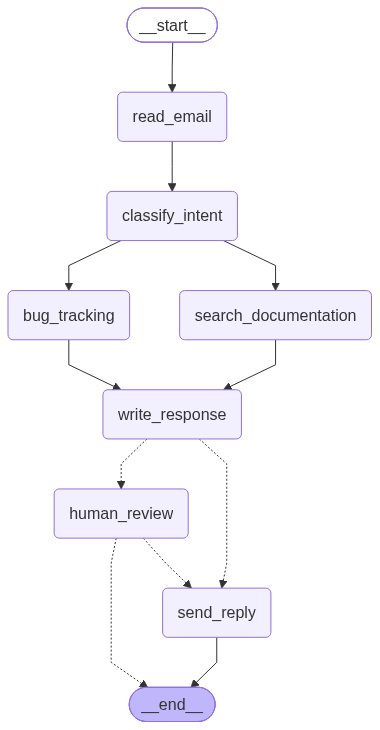

In [112]:
# Dessiner le graphe ne lance pas ses nœuds.
display(Image(email_app.get_graph().draw_mermaid_png()))

**Résultat attendu.** La première cellule affiche le texte Mermaid, puis la seconde
en donne une image. Repérez les deux branches issues de `classify_intent`, leur arrivée
sur `write_response` et les parcours de validation et d'envoi. La synchronisation est
définie dans le code par `add_edge(["search_documentation", "bug_tracking"], "write_response")`.
La compilation et le dessin n'ont encore traité aucun email.

**À vous de jouer — expliquer le rendez-vous.**

Montrez les deux arêtes du fan-out et l’arête du fan-in dans le code.
Si la recherche documentaire finit avant le suivi des bugs, la rédaction peut-elle commencer ?

<details>
<summary>Afficher la correction après votre essai</summary>

Le fan-out correspond aux deux `add_edge` qui partent de `classify_intent`.
Le fan-in est l'arête dont le départ est la liste des deux nœuds. La rédaction attend
les deux branches, y compris lorsque `bug_tracking` termine sans créer de ticket.

</details>

### 5.5 Observer un envoi automatique

Une question simple devrait être classée avec une urgence basse ou moyenne, puis
traitée sans validation humaine. Comparez la classification obtenue, la présence
d'une interruption et l'indicateur d'envoi simulé. Le routage dépend des valeurs
renvoyées par le modèle, pas du nom donné au scénario.

**Objectif.** Tester le parcours automatique sur une demande courante.

**Méthode.** Fournir un email de réinitialisation de mot de passe, un journal initialement vide et un identifiant de fil propre au dossier. Exécuter le workflow et lire la classification, l'indicateur d'interruption et l'état de l'envoi.

In [113]:
email_simple = {
    "email_content": "Bonjour, comment réinitialiser mon mot de passe ? Merci.",
    "sender_email": "client@exemple.fr",
    "email_id": "MAIL-1001",
    "audit": [],
}
# Un fil distinct évite de mélanger ce dossier avec les autres scénarios.
cfg1 = {"configurable": {"thread_id": "mail-1001"}}

# Cette invocation exécute les nœuds et effectue les appels au modèle.
res1 = email_app.invoke(email_simple, cfg1)
print("\nClassification :", res1["classification"])
print("Interruption ? :", "__interrupt__" in res1)
print("Envoyé ? :", res1.get("sent"))

 Envoi simulé à client@exemple.fr (email MAIL-1001)

Classification : {'intent': 'question', 'urgency': 'basse', 'topic': 'Réinitialisation du mot de passe', 'summary': 'Le client demande comment réinitialiser son mot de passe.'}
Interruption ? : False
Envoyé ? : True


**Après exécution — résultat attendu.** Si le modèle classe la demande avec une urgence basse ou moyenne et une intention autre que `complexe`, la sortie doit indiquer `Interruption ? : False` et `Envoyé ? : True`, avec un message d'envoi simulé. Si une interruption apparaît, examinez la classification : elle explique pourquoi la règle a demandé une revue.

### 5.6 Valider un cas sensible

Cet incident devrait recevoir une urgence haute ou critique. Le workflow prépare
alors un brouillon puis attend une décision humaine. Vérifiez la classification :
si le modèle ne déclenche pas la règle HITL, aucune reprise n'est nécessaire.

**Objectif.** Observer l'arrêt du workflow avant l'envoi d'une réponse à un incident sensible.

**Méthode.** Soumettre l'incident sur un fil distinct, puis vérifier la présence de `__interrupt__`. S'il existe, afficher l'urgence et le brouillon complet proposé à la relecture.

In [114]:
email_critique = {
    "email_content": (
        "URGENT : votre service est indisponible depuis 2 heures, "
        "nous perdons des ventes. C'est inacceptable, réagissez immédiatement !"
    ),
    "sender_email": "grand.compte@exemple.fr",
    "email_id": "MAIL-2002",
    "audit": [],
}
# Conserver cette configuration pour reprendre ensuite ce dossier précis.
cfg2 = {"configurable": {"thread_id": "mail-2002"}}

res2 = email_app.invoke(email_critique, cfg2)

# La décision de revue dépend de la classification réelle du modèle.
if "__interrupt__" in res2:
    demande = res2["__interrupt__"][0].value
    print("Validation demandée (urgence =", demande["urgency"], ")\n")
    print("Brouillon proposé :\n")
    display(Markdown(demande["draft_response"]))
else:
    print("Envoyé sans revue :", res2.get("sent"))

Validation demandée (urgence = critique )

Brouillon proposé :



**Objet : Réponse urgente – Indisponibilité du service (Ticket BUG-b89c03f1)**

Bonjour [Nom du client],

Nous vous remercions pour votre signalement et comprenons parfaitement l’urgence de la situation. L’indisponibilité de notre service est effectivement inacceptable, et nous mettons tout en œuvre pour résoudre ce problème au plus vite.

**Actions en cours :**
- Notre équipe technique a été alertée immédiatement et travaille en priorité sur ce ticket (**BUG-b89c03f1**).
- Une investigation approfondie est en cours pour identifier la cause racine et rétablir le service dans les meilleurs délais.
- Nous surveillons activement les indicateurs de performance pour évaluer l’impact et valider la résolution.

**Prochaines étapes :**
- Nous vous tiendrons informé(e) par email dès que le service sera rétabli, avec un rapport détaillé des causes et des mesures correctives mises en place.
- En parallèle, nous analysons les données pour évaluer l’impact sur vos ventes et vous proposer, si nécessaire, des solutions compensatoires.

Nous sommes sincèrement désolés pour les désagréments causés et vous assurons que cette situation est notre priorité absolue. N’hésitez pas à nous contacter directement au [numéro de téléphone] ou à répondre à cet email pour toute information complémentaire.

Bien cordialement,
[Votre prénom et nom]
[Votre poste]
[Nom de l’entreprise]
[Coordonnées : téléphone, email]

---
*PS : Pour suivre l’avancement en temps réel, vous pouvez consulter notre [tableau de bord de statut](lien) ou le ticket BUG-b89c03f1 dans votre espace client.*

**Ton :** Empathique mais professionnel, avec des engagements clairs (transparence, rapidité, compensation si applicable).
**Structure :** Reconnaissance du problème → Actions concrètes → Engagement de suivi → Ouverture au dialogue.

**Après exécution — résultat attendu.** Si la classification déclenche le HITL, une demande de validation et le brouillon complet apparaissent. L'envoi attend alors la décision de la cellule suivante. Sinon, la sortie indique un envoi sans revue : la classification du modèle n'a pas satisfait la règle d'interruption.

### 5.7 Corriger et approuver la réponse

**Objectif.** Terminer le traitement d’un email sensible en permettant à l’humain de compléter le brouillon avant d’autoriser son envoi.

**Méthode.** Le code distingue deux situations selon le résultat du workflow.

1. **Une validation humaine est en attente.**
   La présence de `"__interrupt__"` dans `res2` indique que le workflow s’est interrompu. Le code récupère le brouillon dans le contenu de cette interruption, puis prépare une décision :
   - `approved=True` autorise l’envoi ;
   - `edited_response` contient le brouillon complété par la phrase « Nous vous tenons informé toutes les 30 minutes. ».

2. **Reprendre avec la décision humaine.**
   `email_app.invoke(Command(resume=decision), cfg2)` transmet cette décision à l’attente existante. La configuration `cfg2` conserve le même `thread_id` : on reprend le dossier sans soumettre à nouveau l’email initial.
   Le nœud `human_review` récupère la décision, enregistre le texte corrigé et ajoute une entrée d’audit `approuvé`. Il dirige ensuite le workflow vers `send_reply`, qui simule l’envoi.

3. **Aucune interruption n’a eu lieu.**
   Si le workflow a terminé automatiquement, aucune reprise n’est nécessaire. `final2 = res2` conserve son résultat pour permettre à la cellule suivante de consulter l’audit.

In [115]:
if "__interrupt__" in res2:
    # Décision humaine : on approuve en éditant légèrement le brouillon.
    brouillon = res2["__interrupt__"][0].value["draft_response"]
    decision = {
        "approved": True,
        "edited_response": brouillon + "\n\nNous vous tenons informé toutes les 30 minutes.",
    }

    # Reprendre l’attente existante ; ne pas soumettre à nouveau l’email initial.
    final2 = email_app.invoke(Command(resume=decision), cfg2)
    print("Envoyé ? :", final2.get("sent"))
    print("Audit :", final2["audit"])
else:
    # Fournir un résultat final à la cellule d’audit même sans revue humaine.
    final2 = res2
    print("Aucune interruption : le workflow a déjà terminé.")

 Envoi simulé à grand.compte@exemple.fr (email MAIL-2002)
Envoyé ? : True
Audit : [{'email_id': 'MAIL-2002', 'decision': 'approuvé', 'horodatage': '2026-09-09T09:30:14+00:00'}]


In [119]:
display(Markdown(final2["draft_response"]))

**Objet : Réponse urgente – Indisponibilité du service (Ticket BUG-b89c03f1)**

Bonjour [Nom du client],

Nous vous remercions pour votre signalement et comprenons parfaitement l’urgence de la situation. L’indisponibilité de notre service est effectivement inacceptable, et nous mettons tout en œuvre pour résoudre ce problème au plus vite.

**Actions en cours :**
- Notre équipe technique a été alertée immédiatement et travaille en priorité sur ce ticket (**BUG-b89c03f1**).
- Une investigation approfondie est en cours pour identifier la cause racine et rétablir le service dans les meilleurs délais.
- Nous surveillons activement les indicateurs de performance pour évaluer l’impact et valider la résolution.

**Prochaines étapes :**
- Nous vous tiendrons informé(e) par email dès que le service sera rétabli, avec un rapport détaillé des causes et des mesures correctives mises en place.
- En parallèle, nous analysons les données pour évaluer l’impact sur vos ventes et vous proposer, si nécessaire, des solutions compensatoires.

Nous sommes sincèrement désolés pour les désagréments causés et vous assurons que cette situation est notre priorité absolue. N’hésitez pas à nous contacter directement au [numéro de téléphone] ou à répondre à cet email pour toute information complémentaire.

Bien cordialement,
[Votre prénom et nom]
[Votre poste]
[Nom de l’entreprise]
[Coordonnées : téléphone, email]

---
*PS : Pour suivre l’avancement en temps réel, vous pouvez consulter notre [tableau de bord de statut](lien) ou le ticket BUG-b89c03f1 dans votre espace client.*

**Ton :** Empathique mais professionnel, avec des engagements clairs (transparence, rapidité, compensation si applicable).
**Structure :** Reconnaissance du problème → Actions concrètes → Engagement de suivi → Ouverture au dialogue.

Nous vous tenons informé toutes les 30 minutes.

**Résultat attendu.**

| Situation | Affichage attendu |
|---|---|
| Reprise avec approbation | `Envoyé ? : True`, puis le journal contenant la décision `approuvé`. |
| Traitement déjà terminé | `Aucune interruption : le workflow a déjà terminé.` |

Après approbation, la réponse complétée est conservée dans `final2["draft_response"]`. Elle n’est pas affichée par cette cellule. L’envoi reste simulé : aucun email réel n’est transmis.


> Dans cet atelier, la décision humaine est un dictionnaire fourni dans le code. Dans une application, une interface recueillerait l'approbation, le rejet ou la correction du brouillon, puis transmettrait cette valeur à `Command(resume=...)`.

## 6. Distinguer audit métier et historique technique

L'**audit métier** conserve les décisions utiles au suivi du dossier : classification,
urgence, recours à une validation, décision finale et corrections humaines éventuelles.
Dans cet exemple volontairement simple, `audit` enregistre seulement l'approbation
ou le rejet et son horodatage. La classification et le brouillon corrigé restent
dans l'état ; ils ne constituent pas à eux seuls un journal métier complet.

L'**historique technique** rassemble les checkpoints et états successifs du graphe.
`get_state_history()` permet de les consulter pour comprendre les transitions et
déboguer. La cellule suivante les lit, du plus récent au plus ancien : elle ne
rejoue pas l'exécution. Les checkpoints peuvent aussi servir de point de départ
à une reprise ou à un rejeu explicite.

**Objectif.** Lire séparément les décisions métier et le déroulement technique du dossier sensible.

**Méthode.** Parcourir d'abord `final2['audit']`, puis les instantanés renvoyés par `get_state_history(cfg2)`. Pour chaque checkpoint, afficher la prochaine étape prévue, du plus récent au plus ancien.

In [116]:
# 1) Le journal d'audit métier (nos entrées explicites).
print("=== Journal d'audit (MAIL-2002) ===")
for entree in final2["audit"]:
    print(f"- {entree['horodatage']} · {entree['decision']} · {entree['email_id']}")

# 2) Consulter les checkpoints sans réexécuter le graphe.
print("\n=== Checkpoints traversés (du plus récent au plus ancien) ===")
for snap in email_app.get_state_history(cfg2):
    # Un tuple vide signifie qu’aucun nœud ne reste à exécuter à ce checkpoint.
    prochaine = snap.next or ("aucune étape en attente",)
    print(f"- prochaine étape : {prochaine}")

=== Journal d'audit (MAIL-2002) ===
- 2026-09-09T09:30:14+00:00 · approuvé · MAIL-2002

=== Checkpoints traversés (du plus récent au plus ancien) ===
- prochaine étape : ('aucune étape en attente',)
- prochaine étape : ('send_reply',)
- prochaine étape : ('human_review',)
- prochaine étape : ('write_response',)
- prochaine étape : ('search_documentation', 'bug_tracking')
- prochaine étape : ('classify_intent',)
- prochaine étape : ('read_email',)
- prochaine étape : ('__start__',)


**Après exécution — résultat attendu.** Après approbation, le premier bloc affiche une décision horodatée pour `MAIL-2002`. Sans revue humaine, ce journal peut être vide. Le second bloc affiche les étapes prévues aux différents checkpoints, avec `aucune étape en attente` pour un graphe terminé. Cette lecture ne rejoue aucun nœud et ne renvoie aucun email.

Retenez la différence : le journal métier raconte les décisions que vous choisissez
de tracer ; l'historique technique décrit l'exécution du graphe. Un historique de
checkpoints ne remplace donc pas un audit métier conçu pour les besoins du service.

**À vous de jouer — choisir la bonne trace.**

Où chercheriez-vous la décision d’approbation ? Et le nœud qui attendait une reprise ?
Citez une information métier que le journal de support actuel ne conserve pas explicitement.

<details>
<summary>Afficher la correction après votre essai</summary>

L'approbation se trouve dans `audit`. Le nœud en attente se lit dans les checkpoints,
via l'état et son attribut `next`. Le journal actuel ne trace pas explicitement la
raison du recours à la revue, l'identité du relecteur ou le détail avant/après de sa
correction. Certaines valeurs existent dans l'état, mais pas comme événements du journal.

</details>

In [117]:
conn_email.close()

## 7. Conclusion

Un workflow rend le chemin d'exécution explicite. LangGraph en organise l'état,
les transitions et les branches parallèles, dont le fan-in synchronise les résultats.
`interrupt()` suspend l'exécution ; un checkpointer persistant conserve cette attente
au-delà du processus. `Command` permet de reprendre ou de mettre à jour l'état et router.

L'intervention humaine devient une règle métier : elle se déclenche lorsque le
risque ou la complexité le justifie. L'audit métier explique les décisions ;
l'historique technique aide à comprendre et à reprendre l'exécution.

**À vous de jouer — vérifier les acquis dans la conclusion.**

Reprenez les fonctions `revue_humaine`, `finaliser` et `archiver` déjà définies.
À partir de ce squelette, reconstruisez le graphe sans copier sa cellule d’assemblage :

```python
from uuid import uuid4

verification = StateGraph(RevueState)
# Enregistrer les trois nœuds.
# Relier START à la revue, puis chacune des deux destinations à END.
# Compiler avec un checkpointer en mémoire.
# Lancer une revue avec un nouveau thread_id et vérifier l'interruption.
# Reprendre avec un rejet, puis afficher le verdict et l'audit.
```

**Vous avez atteint l’objectif si vous pouvez :**

- dessiner les parcours et expliquer où `Command` choisit la destination ;
- obtenir une interruption puis un verdict `archivé (rejeté)` sur le même dossier ;
- expliquer pourquoi le document reste dans l’état et pourquoi l’audit s’enrichit ;
- indiquer ce qui serait à conserver pour reprendre avec SQLite après un redémarrage ;
- expliquer quand le support sollicite une personne et pourquoi il attend les deux branches.

Si une explication reste difficile, revenez à l’exercice de la section correspondante.

<details>
<summary>Afficher la correction après votre essai</summary>

```python
from uuid import uuid4

verification = StateGraph(RevueState)
verification.add_node("revue_humaine", revue_humaine)
verification.add_node("finaliser", finaliser)
verification.add_node("archiver", archiver)
verification.add_edge(START, "revue_humaine")
verification.add_edge("finaliser", END)
verification.add_edge("archiver", END)
verification_app = verification.compile(checkpointer=InMemorySaver())
cfg_verification = {"configurable": {"thread_id": f"verification-{uuid4().hex}"}}
pause = verification_app.invoke({"document": "Note à relire."}, cfg_verification)
print(pause["__interrupt__"][0].value)
verdict = verification_app.invoke(Command(resume={"choix": "rejeter"}), cfg_verification)
print(verdict["verdict"], verdict["audit"])
```

Le rejet route vers `archiver`. Les mises à jour ordinaires remplacent les champs
concernés et laissent les autres présents ; le reducer ajoute les entrées d'audit.
Une reprise depuis SQLite demande les définitions du graphe, la base conservée et le
même identifiant. Dans le support, risque ou complexité imposent la revue ; le fan-in
assure que la rédaction reçoit les résultats des deux branches.

</details>

### 7.1 Pour aller plus loin

Remplacez la recherche simulée par le module documentaire du thème suivant, ou
enrichissez l'audit pour tracer la classification, le choix de revue et les corrections.
Un rejeu depuis un checkpoint antérieur est un exercice distinct : il peut réexécuter
des nœuds et leurs appels externes.

### 7.2 Ressources

- [LangGraph — Workflows et agents](https://docs.langchain.com/oss/python/langgraph/workflows-agents)
- [LangGraph — Interruptions et reprise](https://docs.langchain.com/oss/python/langgraph/interrupts)
- [LangGraph — Persistance et checkpoints](https://docs.langchain.com/oss/python/langgraph/persistence)
- [Mistral — Appels de fonctions](https://docs.mistral.ai/capabilities/function_calling/)